In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

1. Load the uploaded CSV file

In [2]:
file_path = "BirdSpecies_dataset.csv"
df = pd.read_csv(file_path, encoding="latin1")

2. Data Description

In [3]:
df.head()

,BodyLength,Wingspan,Weight,PlumageColorHead,PlumageColorBack,PlumageColorBelly,PlumageColorWings,PlumageColorTail,BeakLength,BeakWidth,...,SeedDispersalRole,InterspecificInteraction,IntraspecificInteraction,LearningAbility,ToolUse,ParentalCareLevel,BathingBehavior,GroomingBehavior,FlightSpeed,SpeciesClass
0,5.210,9.746,5.815,8.831,1.580,2.257,6.399,3.746,7.541,4.286,...,8.122,7.139,3.319,0.045,4.456,7.167,7.826,7.316,4.245,4
1,2.275,2.496,6.104,1.692,0.856,2.056,0.110,1.277,8.491,5.665,...,6.354,7.772,6.739,2.824,5.807,2.852,3.478,6.132,4.471,4
2,5.927,1.357,5.936,9.536,1.820,7.886,8.658,4.401,5.786,1.107,...,2.389,3.796,3.149,5.075,4.251,4.682,0.966,9.572,9.364,5
3,6.022,6.402,3.772,2.884,8.638,4.623,2.129,1.352,9.475,8.545,...,8.634,8.433,0.997,6.761,4.675,4.749,6.081,6.774,4.162,3
4,7.816,8.374,0.155,4.262,8.726,2.452,1.046,7.110,5.689,0.559,...,8.851,3.259,3.426,0.555,6.317,2.686,8.380,9.903,3.365,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   BodyLength                25000 non-null  float64
 1   Wingspan                  25000 non-null  float64
 2   Weight                    25000 non-null  float64
 3   PlumageColorHead          25000 non-null  float64
 4   PlumageColorBack          25000 non-null  float64
 5   PlumageColorBelly         25000 non-null  float64
 6   PlumageColorWings         25000 non-null  float64
 7   PlumageColorTail          25000 non-null  float64
 8   BeakLength                25000 non-null  float64
 9   BeakWidth                 25000 non-null  float64
 10  BeakShape                 25000 non-null  float64
 11  BeakColor                 25000 non-null  float64
 12  LegLength                 25000 non-null  float64
 13  LegColor                  25000 non-null  float64
 14  FootType         

In [5]:
df.shape

(25000, 61)

In [6]:
df.describe()

,BodyLength,Wingspan,Weight,PlumageColorHead,PlumageColorBack,PlumageColorBelly,PlumageColorWings,PlumageColorTail,BeakLength,BeakWidth,...,SeedDispersalRole,InterspecificInteraction,IntraspecificInteraction,LearningAbility,ToolUse,ParentalCareLevel,BathingBehavior,GroomingBehavior,FlightSpeed,SpeciesClass
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,5.027980,4.991811,4.968451,4.981052,5.039656,5.044007,4.998379,4.995770,5.010424,4.993987,...,5.006204,4.984802,4.968768,4.964604,5.007766,5.001795,4.996408,5.042066,4.989516,2.496960
std,2.879286,2.896154,2.896407,2.886239,2.890039,2.892905,2.897420,2.890657,2.895861,2.873523,...,2.895825,2.897205,2.895149,2.872799,2.890636,2.898771,2.875909,2.878425,2.901216,1.704613
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,0.000000,0.001000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.538000,2.464000,2.450000,2.478000,2.526000,2.524000,2.494000,2.506000,2.479000,2.519000,...,2.498000,2.481000,2.468750,2.484000,2.513750,2.486750,2.514500,2.536500,2.466000,1.000000
50%,5.050000,5.026000,4.937000,4.985000,5.062500,5.069500,5.005000,4.962000,5.023000,4.989000,...,4.989000,4.964500,4.917000,4.946000,4.997000,5.004000,4.978500,5.057500,4.991500,2.000000
75%,7.528250,7.479000,7.481000,7.457000,7.544000,7.568000,7.522250,7.509000,7.545000,7.469000,...,7.518250,7.500000,7.483250,7.445000,7.532000,7.516000,7.485250,7.523250,7.490000,4.000000
max,10.000000,10.000000,10.000000,9.999000,9.999000,10.000000,10.000000,10.000000,10.000000,9.999000,...,9.997000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000


Missing Values

In [7]:
df.isna().sum()

BodyLength           0
Wingspan             0
Weight               0
PlumageColorHead     0
PlumageColorBack     0
                    ..
ParentalCareLevel    0
BathingBehavior      0
GroomingBehavior     0
FlightSpeed          0
SpeciesClass         0
Length: 61, dtype: int64

Description Plots

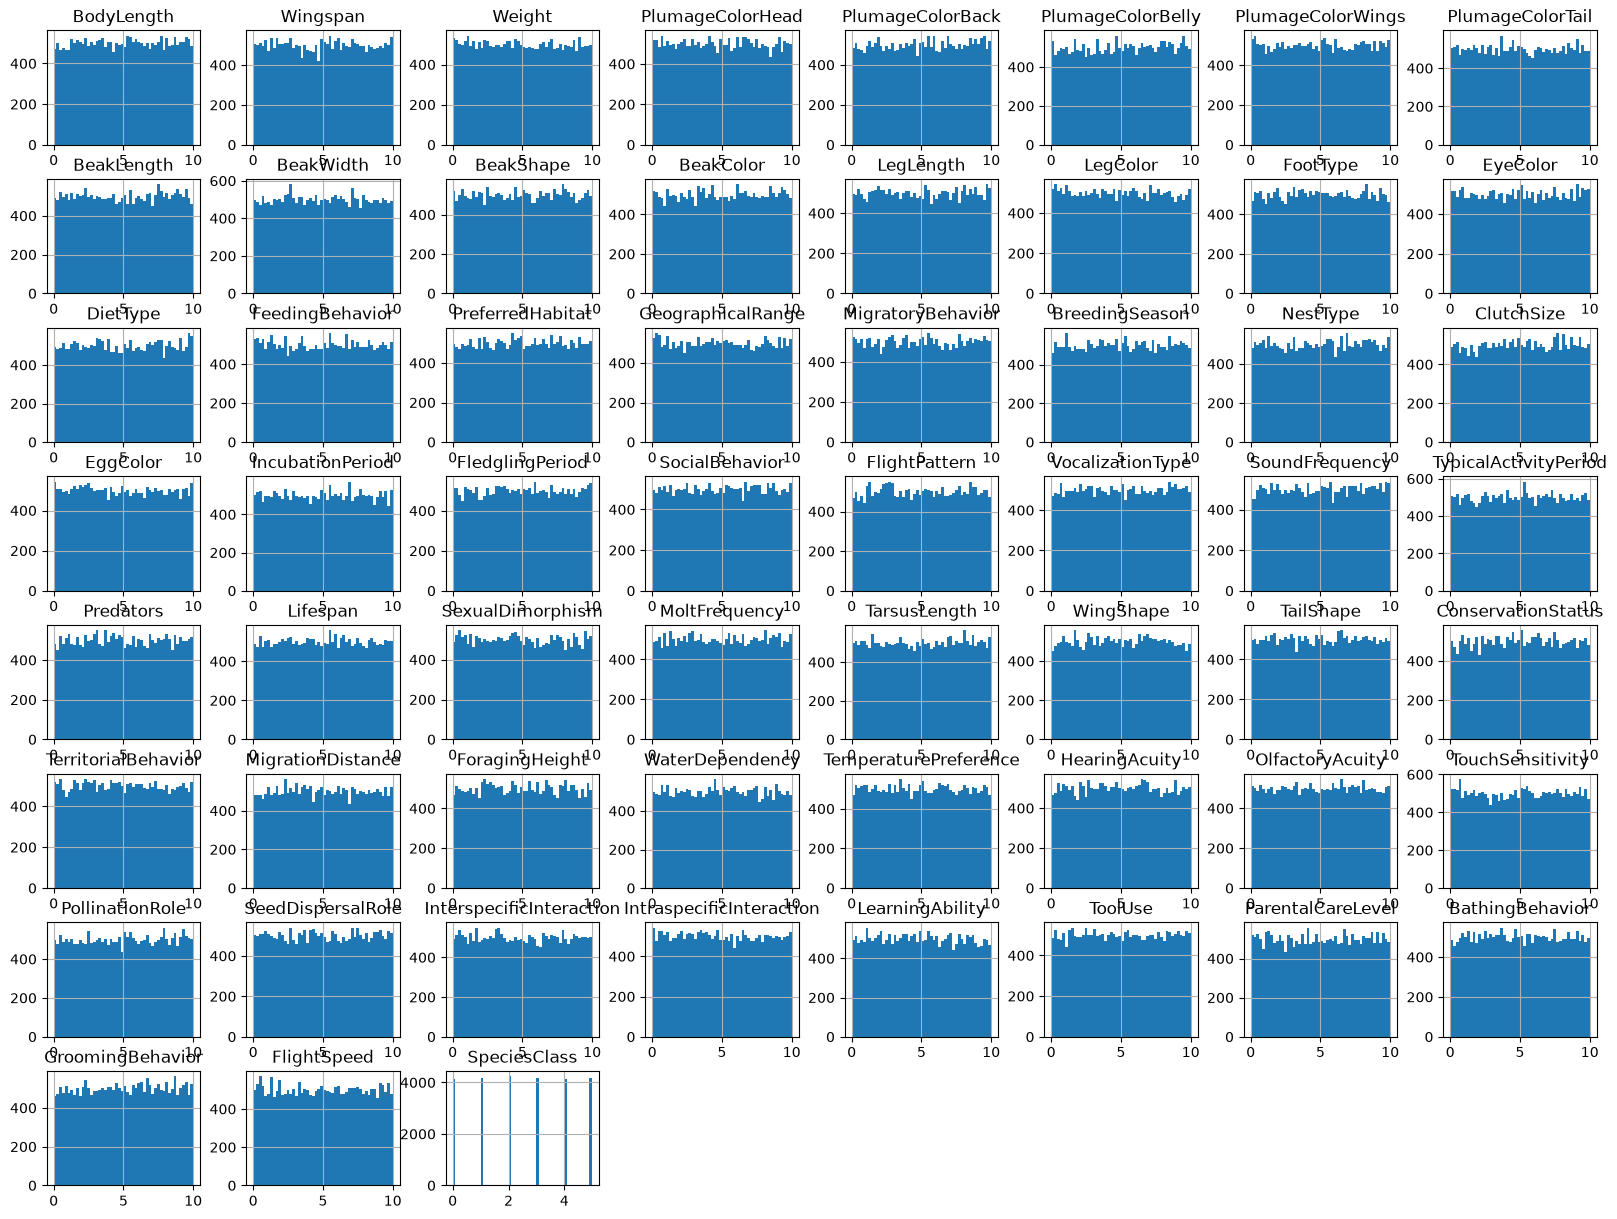

In [8]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20, 15))
plt.show()

Correlation Matrix

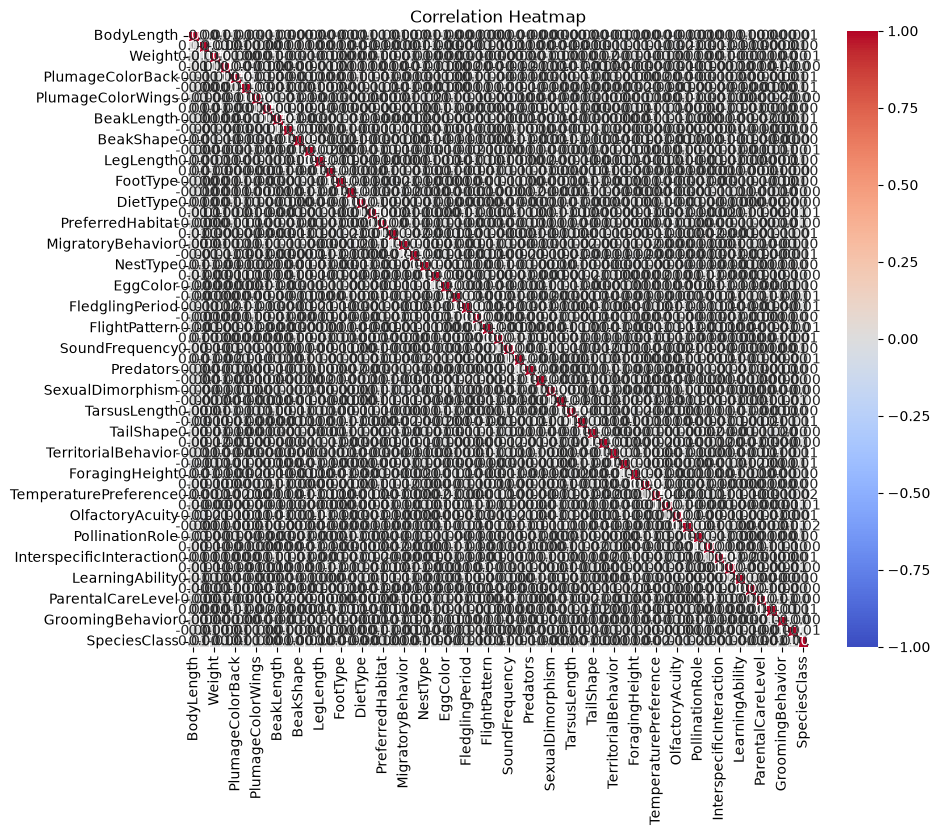

In [9]:
corr_matrix = df.corr(numeric_only=True)

# 3. Set up the matplotlib figure and create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values in cells
    cmap="coolwarm",  # Choose a diverging color palette
    vmin=-1,
    vmax=1,  # Fix the scale from -1 to 1
    fmt=".2f",  # Format the numbers to 2 decimal places
    linewidths=0.5,
)  # Add thin lines between cells

# 4. Display the plot
plt.title("Correlation Heatmap")
plt.show()

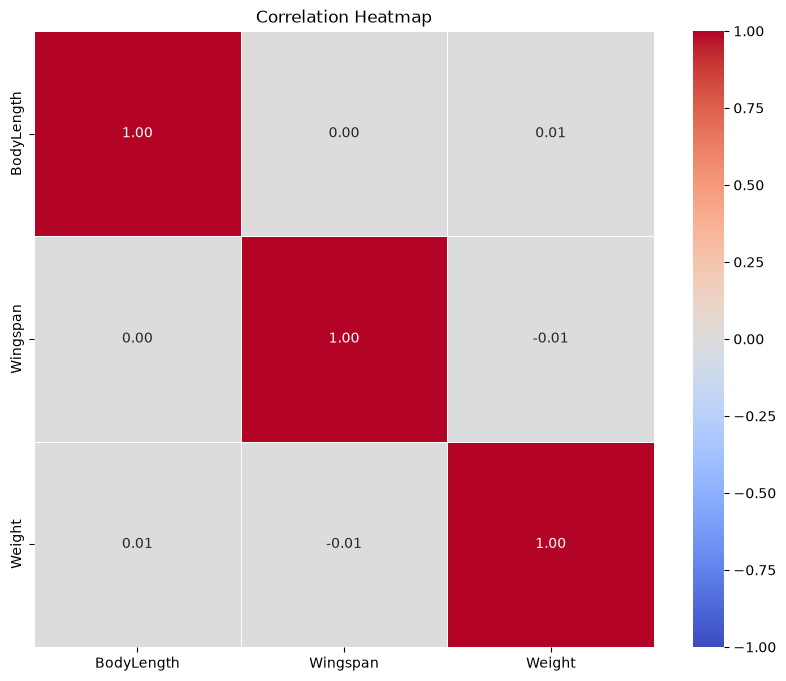

In [10]:
df_new = df[["BodyLength", "Wingspan", "Weight"]]
corr_matrix = df_new.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values in cells
    cmap="coolwarm",  # Choose a diverging color palette
    vmin=-1,
    vmax=1,  # Fix the scale from -1 to 1
    fmt=".2f",  # Format the numbers to 2 decimal places
    linewidths=0.5,
)  # Add thin lines between cells

# 4. Display the plot
plt.title("Correlation Heatmap")
plt.show()

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

y = df["SpeciesClass"]
X = df.drop(columns="SpeciesClass")
X = X.select_dtypes(include=("number"))

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


hgbc = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)

In [12]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,  # Target dimension (usually 2 or 3)
    perplexity=30.0,  # Number of effective nearest neighbors (5 to 50)
    learning_rate="auto",  # Step size for gradient descent optimization
    max_iter=5000,  # Number of iterations for convergence
    random_state=0,  # Seed for reproducible layout results
)
X_embedded = tsne.fit_transform(X)

In [13]:
y = df["SpeciesClass"]
X_trim = X_embedded.copy()

X_train_trim, X_test_trim, y_train_trim, y_test_trim = train_test_split(
    X_trim, y, random_state=42
)


hgbc_trim = HistGradientBoostingClassifier(random_state=0).fit(
    X_train_trim, y_train_trim
)

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = hgbc.predict(X_test)
y_pred_trim = hgbc_trim.predict(X_test_trim)

# 3. Calculate error and performance metrics
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1.0 - accuracy
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy_trim = accuracy_score(y_test_trim, y_pred_trim)
error_rate_trim = 1.0 - accuracy_trim
conf_matrix_trim = confusion_matrix(y_test_trim, y_pred_trim)
report_trim = classification_report(y_test_trim, y_pred_trim)

print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)


print(f"Accuracy Trimmed: {accuracy_trim:.4f}")
print(f"Error Rate Trimmed: {error_rate_trim:.4f}\n")
print("Confusion Matrix Trimmed:")
print(conf_matrix_trim)
print("\nClassification Report Trimmed:")
print(report_trim)

Accuracy: 0.1618
Error Rate: 0.8382

Confusion Matrix:
[[151 166 191 221 137 171]
 [161 165 199 209 162 177]
 [188 169 186 203 147 175]
 [135 168 204 214 132 146]
 [176 143 204 225 129 164]
 [163 172 166 201 164 166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.15      0.15      1037
           1       0.17      0.15      0.16      1073
           2       0.16      0.17      0.17      1068
           3       0.17      0.21      0.19       999
           4       0.15      0.12      0.13      1041
           5       0.17      0.16      0.16      1032

    accuracy                           0.16      6250
   macro avg       0.16      0.16      0.16      6250
weighted avg       0.16      0.16      0.16      6250

Accuracy Trimmed: 0.1630
Error Rate Trimmed: 0.8370

Confusion Matrix Trimmed:
[[211  99 225 188 157 157]
 [193  91 254 207 165 163]
 [206 104 240 192 163 163]
 [192  79 256 171 152 149]
 [212  92 239 188 149 161]
 

In [15]:
from sklearn.model_selection import GridSearchCV

# parameter grid
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_iter": [50, 100, 150],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
}

# grid search
grid_search = GridSearchCV(
    estimator=hgbc,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

# search
grid_search.fit(X_train, y_train)

# results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'l2_regularization': 1.0, 'learning_rate': 0.2, 'max_iter': 50, 'max_leaf_nodes': 63, 'min_samples_leaf': 20}
Best CV Score: 0.1717


In [17]:
hgbc_cv = HistGradientBoostingClassifier(
    random_state=0,
    l2_regularization=1,
    learning_rate=0.2,
    max_iter=50,
    max_leaf_nodes=63,
    min_samples_leaf=20,
).fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_cv = hgbc_cv.predict(X_test)


# calculate error and performance metrics
accuracy_cv = accuracy_score(y_test, y_pred_cv)
error_rate_cv = 1.0 - accuracy_cv
conf_matrix_cv = confusion_matrix(y_test, y_pred_cv)
report_cv = classification_report(y_test, y_pred_cv)


print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)


print(f"Accuracy CV: {accuracy_cv:.4f}")
print(f"Error Rate CV: {error_rate_cv:.4f}\n")
print("Confusion Matrix CV:")
print(conf_matrix_cv)
print("\nClassification Report CV:")
print(report_cv)

Accuracy: 0.1618
Error Rate: 0.8382

Confusion Matrix:
[[151 166 191 221 137 171]
 [161 165 199 209 162 177]
 [188 169 186 203 147 175]
 [135 168 204 214 132 146]
 [176 143 204 225 129 164]
 [163 172 166 201 164 166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.15      0.15      1037
           1       0.17      0.15      0.16      1073
           2       0.16      0.17      0.17      1068
           3       0.17      0.21      0.19       999
           4       0.15      0.12      0.13      1041
           5       0.17      0.16      0.16      1032

    accuracy                           0.16      6250
   macro avg       0.16      0.16      0.16      6250
weighted avg       0.16      0.16      0.16      6250

Accuracy CV: 0.1690
Error Rate CV: 0.8382

Confusion Matrix CV:
[[176 189 171 155 157 189]
 [159 184 180 188 186 176]
 [173 191 182 161 196 165]
 [149 164 167 168 173 178]
 [172 167 211 169 163 159]
 [156 159 201 16

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X_numeric = df.drop(columns="SpeciesClass").select_dtypes(include="number")
y = df["SpeciesClass"]

mi_values = mutual_info_classif(X_numeric, y, random_state=42)

mi_results = pd.Series(mi_values, index=X_numeric.columns).sort_values(ascending=False)

print(mi_results.head(20))

TemperaturePreference       0.010503
TerritorialBehavior         0.008412
FeedingBehavior             0.008364
SocialBehavior              0.007225
SexualDimorphism            0.007078
SoundFrequency              0.006111
OlfactoryAcuity             0.005883
DietType                    0.005152
BeakLength                  0.004440
IntraspecificInteraction    0.004358
TailShape                   0.004356
PlumageColorWings           0.004056
ForagingHeight              0.003087
BeakWidth                   0.003065
PlumageColorTail            0.002928
BeakColor                   0.002796
ToolUse                     0.002700
WaterDependency             0.002434
NestType                    0.002134
GeographicalRange           0.001866
dtype: float64
